
<style>
.jp-RenderedHTMLCommon, .jp-RenderedMarkdown {
    line-height: 1.6;
    font-size: 16px;
}
.report-box {
    border: 1.5px solid #1f3b66;
    border-radius: 10px;
    padding: 18px 22px;
    margin: 10px 0 18px 0;
    background: #f8fbff;
}
.question-box {
    border-left: 5px solid #1f3b66;
    background: #f5f8fc;
    padding: 12px 16px;
    margin: 12px 0;
}
.answer-box {
    border-left: 5px solid #6b7280;
    background: #fafafa;
    padding: 12px 16px;
    margin: 12px 0;
}
.figure-caption {
    text-align: center;
    font-style: italic;
    color: #444;
    margin-top: 6px;
    margin-bottom: 16px;
}
.centered {
    text-align: center;
}
.smallcaps {
    letter-spacing: 0.05em;
    text-transform: uppercase;
    color: #1f3b66;
    font-weight: 700;
}
hr {
    border: none;
    border-top: 1px solid #d0d7de;
    margin: 24px 0;
}
table {
    margin-left: auto;
    margin-right: auto;
}
</style>



<div class="centered">
<p class="smallcaps">Université Catholique de Louvain</p>
<p><strong>École Polytechnique de Louvain</strong></p>

# Devoir 2

<p><strong>Cours :</strong> LFKY1101 Chimie et physique appliquées – aspects technologiques</p>
<p><strong>Groupe :</strong> Groupe 1</p>
</div>

<div class="report-box">

**Étudiant.e.s :**
- de Villenfagne de Vogelsanck Eléonore  
- Isaac Célia  
- Jacquet Léa  
- Le Anh-Tien  
- Petitjean Louis-Frédéric  

**Enseignant.e.s :**
- Abreu Araujo Flavio  
- Benoît Hackens  
- Jacques Pascal  
- Luis Alconero Patricia  

Des parties de ce rapport ont été reformulées à l’aide de l’IA.  

**Date :** 20 mars 2026  




## Sommaire

1. Introduction  
2. Prise en main des données  
3. Visualisation et identification des régimes  
4. Principe physique de l’ATD  
5. Extraction des grandeurs caractéristiques  
6. Estimation de la chaleur latente  
7. Annexe A — Code Python  
8. Références


In [60]:
# Imports de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import Image, display, IFrame, Markdown
from scipy.signal import savgol_filter, find_peaks

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# À adapter avec le vrai nom de votre fichier CSV
csv_path = "tmp117_log_labo_6mars.csv"


# 1 Introduction

L’objectif de ce travail est de se familiariser avec le traitement de données expérimentales ainsi qu’avec l’analyse des incertitudes. Il consiste à déterminer certaines propriétés du gallium, notamment sa température de fusion et sa chaleur spécifique.

Les données exploitées proviennent de deux capteurs de température : l’un est en contact avec un échantillon de gallium, tandis que l’autre sert de référence et est placé dans le même environnement thermique sans contact avec l’échantillon.

Le dispositif expérimental repose sur le principe de l’analyse thermique différentielle (ATD), qui permet d’observer les transitions de phase à partir des différences de température mesurées entre les deux capteurs. Le schéma du montage expérimental est présenté à la figure 1.


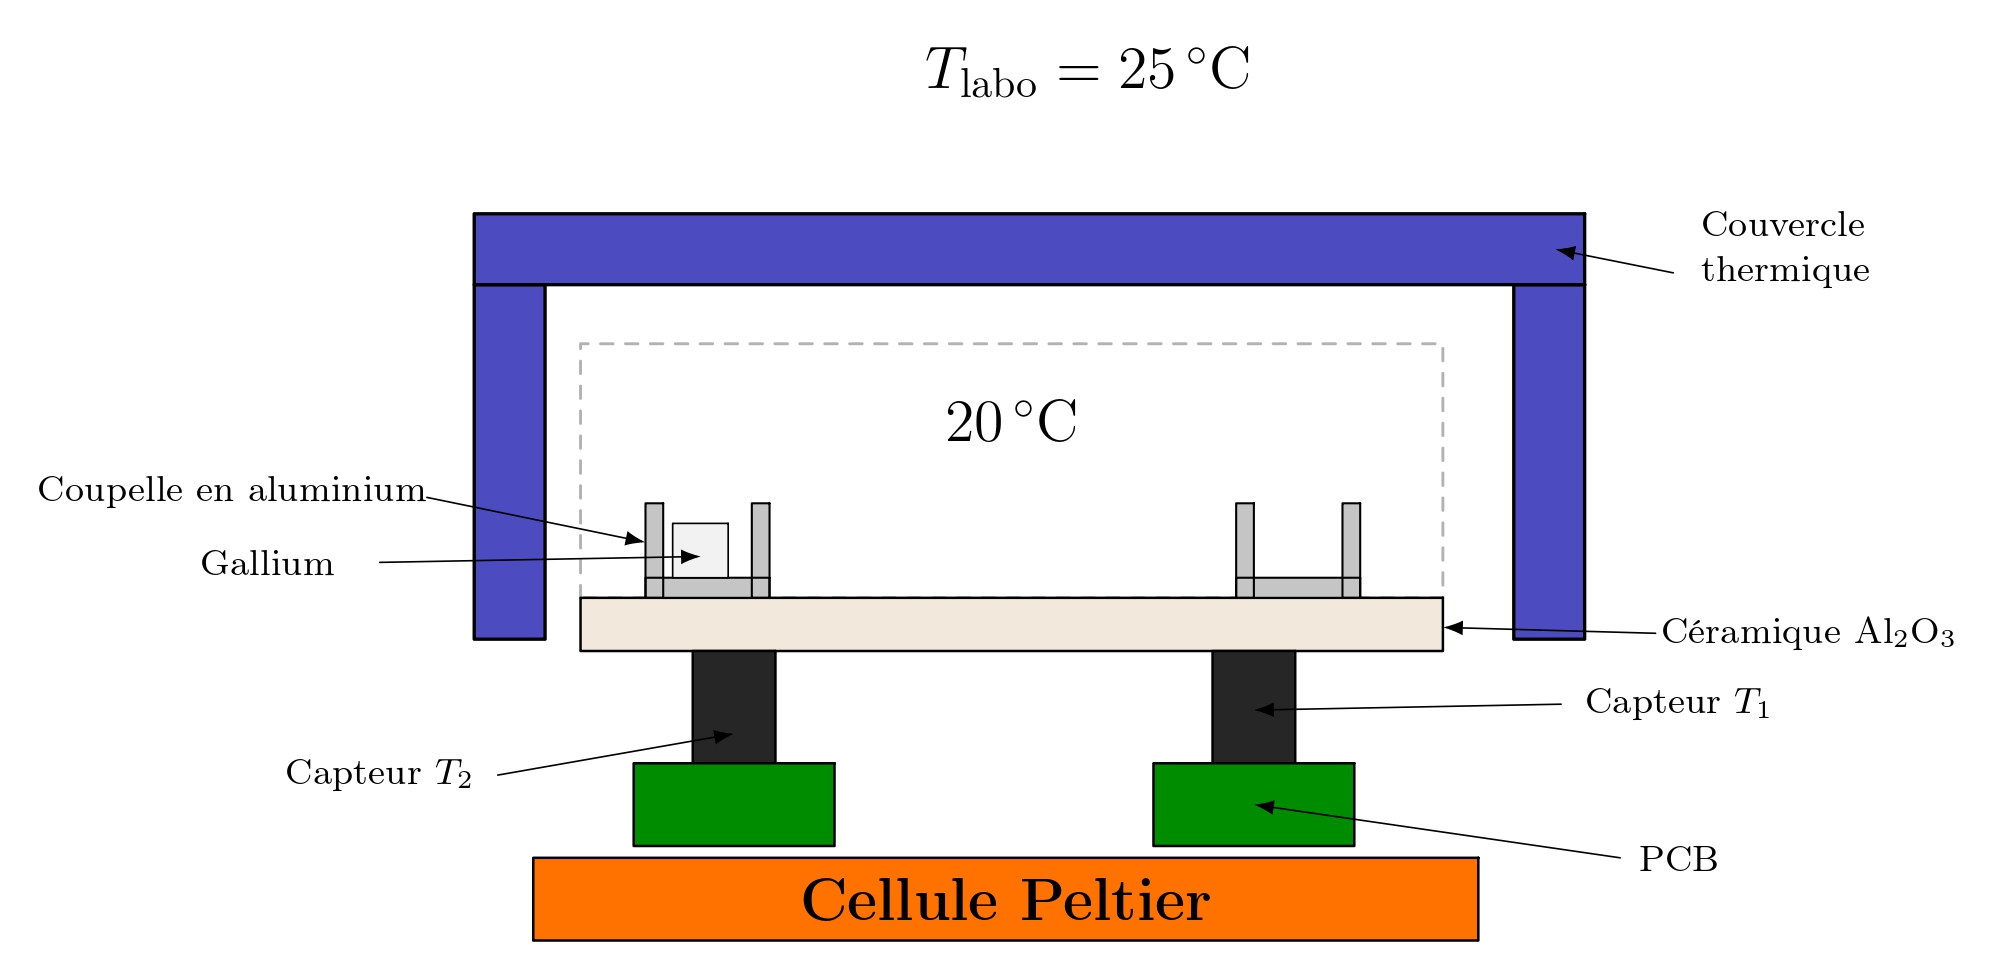

**Figure 1 — Schéma du dispositif expérimental**

In [61]:

display(Image(filename='image/schema_expe_page.jpg'))
display(Markdown("**Figure 1 — Schéma du dispositif expérimental**"))


## 1.1 Prise en main des données

<div class="question-box">

### Q1  
Chargez le fichier CSV avec pandas et affichez les premières lignes.

</div>

<div class="answer-box">

### Réponse

</div>


In [62]:
df = pd.read_csv(csv_path)

# Aperçu
display(df.head())

# Types
print(df.dtypes)

# Nombre de points
n_points = len(df)
print("Nombre de points :", n_points)

# Durée totale
duree_totale = df["Elapsed_Time_s"].iloc[-1] - df["Elapsed_Time_s"].iloc[0]
print("Durée totale de l’expérience [s] :", duree_totale)

,Elapsed_Time_s,Timestamp,T1_C,T2_C,Skew_ms,Delta_T_C
0,0.000,2026-03-06T12:07:31.375616,-9.5391,-9.3125,0.854,-0.2266
1,0.225,2026-03-06T12:07:31.600212,-9.5313,-9.3047,0.854,-0.2266
2,0.468,2026-03-06T12:07:31.843381,-9.5234,-9.3047,0.824,-0.2188
3,0.708,2026-03-06T12:07:32.083552,-9.5234,-9.2969,0.854,-0.2266
4,0.946,2026-03-06T12:07:32.321221,-9.5156,-9.3047,0.885,-0.2109


Elapsed_Time_s    float64
Timestamp             str
T1_C              float64
T2_C              float64
Skew_ms           float64
Delta_T_C         float64
dtype: object
Nombre de points : 4295
Durée totale de l’expérience [s] : 1016.199



**Table 1 – Mesures de température et écart**



<div class="question-box">

### Q2  
Calculez l’intervalle d’échantillonnage moyen et son écart-type à partir de la colonne `Elapsed_Time_s`. Comparez avec la fréquence d’échantillonnage nominale de 4 Hz. La mesure est-elle régulière ? Que révèle la colonne `Skew_ms` sur la synchronisation des deux capteurs ?

</div>

<div class="answer-box">

### Réponse

L’intervalle de temps a été calculé grâce à la colonne Time (s) obtenue dans le fichier CSV, en calculant les intervalles entre les temps consécutifs. L’intervalle moyen est de 0,237 s, avec un écart-type de 0,0098 s. Si on compare avec la fréquence nominale de 4 Hz, ce qui est égal à $\frac{1}{T}$ donc 0,25 s, on remarque que les valeurs mesurées sont un peu plus rapprochés. L’écart reste faible et ne remet donc pas en cause la validité des mesures. L’écart-type est faible aussi, environ 4% de la valeur moyenne. On a donc une bonne régularité de la prise de mesure. La colonne de Skew (ms) représente la synchronisation entre les capteurs. Le décalage moyen observé est 0,86 ms et l’écart-type moyen est de 0,068 ms. Ces valeurs faibles montrent que les deux sondes sont bien synchronisées.

</div>



## 1.2 Visualisation et identification des régimes

<div class="question-box">

### Q3  
Tracez $T_1(t)$ et $T_2(t)$ sur le même graphe (axes légendés, unités). Identifiez et délimitez visuellement les deux régimes de l’expérience : chauffe et refroidissement.

</div>

<div class="answer-box">

### Réponse

</div>


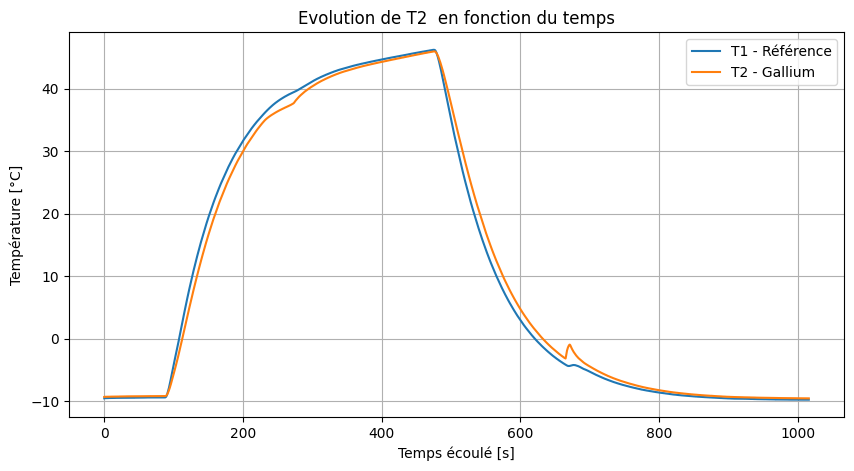

**Figure 2 — SÉvolution des températures T1 et T2 en fonction du temps**

In [63]:
plt.figure(figsize=(10,5))
plt.plot(df["Elapsed_Time_s"], df["T1_C"], label="T1 - Référence")
plt.plot(df["Elapsed_Time_s"], df["T2_C"], label="T2 - Gallium")
plt.xlabel("Temps écoulé [s]")
plt.ylabel("Température [°C]")
plt.title("Evolution de T2  en fonction du temps")
plt.legend()
plt.grid(True)
plt.show()

display(Markdown("**Figure 2 — SÉvolution des températures T1 et T2 en fonction du temps**"))


Le graphe de la figure 2 représente les températures $T_1(t)$ (capteur de référence) et $T_2(t)$ (capteur au contact du gallium) en fonction du temps permettant d’observer les différentes phases de l’expérience.

Tout d’abord, les deux températures augmentent progressivement. Cette phase correspond au régime de chauffe du système lorsque la résistance chauffante est activée. Ensuite, après l’arrêt de la chauffe, les deux températures diminuent progressivement et le système passe dans un régime de refroidissement.

On observe que les deux températures ne se superposent pas parfaitement notamment autour de certaines températures. En effet, à certains endroits, l’évolution du $T_2(t)$ devient plus lente. Cela est dû aux transitions de phase du gallium au cours desquelles l’énergie thermique est utilisée pour changer l’état du matériau (fusion ou solidification) au lieu d’augmenter ou diminuer sa température.



<div class="question-box">

### Q4  
Tracez $\Delta t(t) = T_1(t) - T_2(t)$ en fonction du temps. Décrivez qualitativement l’allure de la courbe. Où se situent les anomalies les plus marquées ?

</div>

<div class="answer-box">

### Réponse

</div>


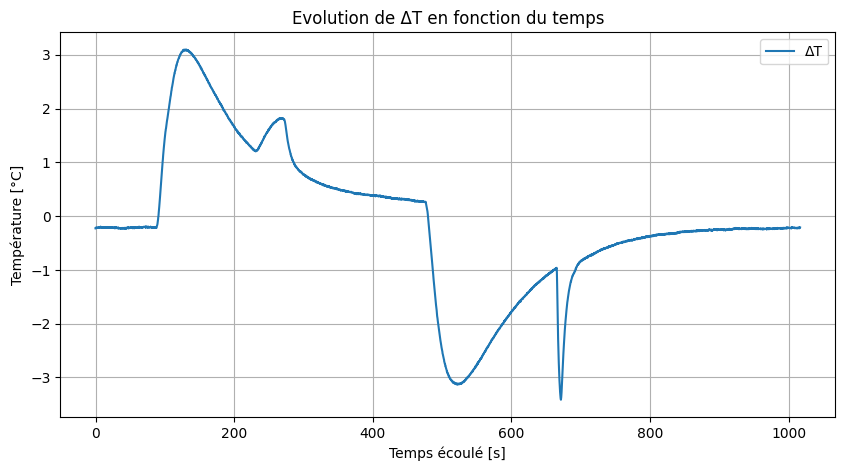

**Figure 3 — Evolution de ΔT en fonction du temps**

In [68]:
plt.figure(figsize=(10,5))
plt.plot(df["Elapsed_Time_s"], df["Delta_T_C"], label="ΔT")
plt.xlabel("Temps écoulé [s]")
plt.ylabel("Température [°C]")
plt.title("Evolution de ΔT en fonction du temps")
plt.legend()
plt.grid(True)
plt.show()

display(Markdown("**Figure 3 — Evolution de ΔT en fonction du temps**")) 


Lorsque le système est loin des transitions de phase, la différence de température reste assez faible et varie de manière régulière.

Cependant, lors des transitions de phase, des anomalies marquées apparaissent dans le signal différentiel. En effet, un pic positif apparaît lors de la fusion car la chaleur demandée au changement d’état du gallium ralentit l’augmentation de sa température. De même qu’un creux négatif apparaît lors de la solidification car la chaleur qui est libérée pendant ce changement d’état ralentit le refroidissement du matériau. Ces anomalies correspondent donc aux instants où le gallium change d’état.



## 1.3 Principe physique de l’ATD

<div class="question-box">

### Q5  
Lors de la fusion du gallium, $T_2$ absorbe la chaleur latente et sa montée en température ralentit par rapport à $T_1$. Expliquez, à partir d’un bilan enthalpique, pourquoi $\Delta t = T_1 - T_2$ devient positif à la fusion et négatif à la solidification. Schématisez la situation.

</div>

<div class="answer-box">

### Réponse

Dans l’expérience d’Analyse Thermique Différentielle (ATD), deux capteurs mesurent la température dans le même environnement thermique :

- $T_1$ : capteur de référence, placé dans l’environnement, mais sans échantillon.
- $T_2$ : capteur en contact thermique avec l’échantillon de gallium.

On étudie la différence de température :

$$\Delta T = T_1 - T_2$$

Lorsqu’une transition de phase se produit, l’énergie échangée avec le système ne sert pas directement à modifier la température, mais à changer l’état du matériau. Ce phénomène correspond à une variation d’enthalpie de changement d’état.

La quantité de chaleur associée à cette transition est donnée par la formule :

$$\Delta H = mL$$

où :

- $m$ est la masse du matériau,
- $L$ la chaleur latente massique (J/kg).

La chaleur latente correspond donc à l’énergie absorbée ou libérée lors d’une transition de phase à température constante. [1]

#### Fusion du gallium, solide $\Rightarrow$ liquide (chauffer)

Lorsque le système est chauffé, les deux capteurs voient leur température augmenter. Cependant, lorsque la température approche la température de fusion du gallium ($\approx 29{.}76^\circ\mathrm{C}$), une partie de l’énergie thermique fournie à l’échantillon ne sert plus à augmenter sa température.

Cette énergie est utilisée pour transformer le solide en liquide. Elle correspond à la chaleur latente de fusion.

$$\Delta H = +mL_f$$

Pendant cette transition :

- le capteur $T_1$ continue de suivre la température de l’environnement, car il n’est pas en contact avec le gallium.
- le capteur $T_2$ chauffe plus lentement car une partie de l’énergie thermique fournie est utilisée pour la fusion du gallium plutôt que pour augmenter sa température.

L’énergie absorbée sert principalement à rompre les liaisons dans le réseau cristallin du solide et à permettre la formation de la phase liquide. La température de l’échantillon augmente donc plus lentement.

On obtient alors :

$$T_1 > T_2 \Rightarrow \Delta T = T_1 - T_2 > 0$$

Sur la courbe $\Delta T(t)$, la fusion apparaît ainsi sous la forme d’un pic positif.

#### Solidification du gallium, liquide $\Rightarrow$ solide (refroidissement)

Lors du refroidissement, le phénomène inverse se produit. Lorsque le gallium liquide se solidifie, il libère l’enthalpie de fusion précédemment absorbée :

$$\Delta H = -mL_f$$

Cette énergie thermique est restituée au milieu environnant, ce qui ralentit la diminution de la température de l’échantillon.

Ainsi :

- $T_1$ continue de diminuer, car il n’est pas en contact avec le gallium.
- $T_2$ diminue plus lentement car l’échantillon libère de la chaleur lors de la solidification.

On obtient alors :

$$T_2 > T_1 \Rightarrow \Delta T = T_1 - T_2 < 0$$

Sur la courbe $\Delta T(t)$, la solidification apparaît donc comme un pic négatif.

-=⇒ Donc, lors d’une transition de phase, l’énergie échangée modifie l’enthalpie du système. Effectivement, la fusion nécessite un apport d’énergie, ce qui implique $\Delta H > 0$, tandis que la solidification libère de l’énergie, ce qui correspond à $\Delta H < 0$.



</div>


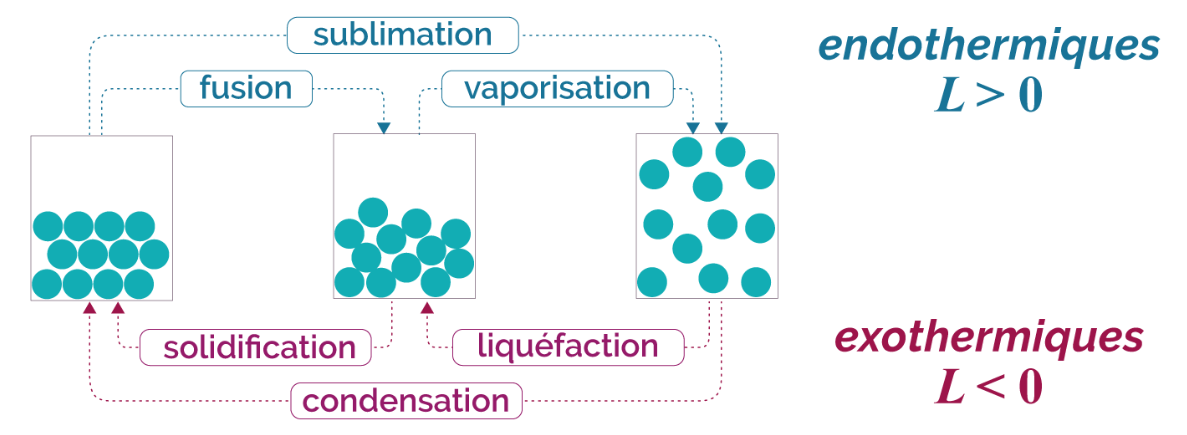

In [65]:
display(Image(filename='image/schema_phase.png'))

1. L’image vient du site : https://www.maxicours.com/se/cours/l-energie-de-changement-d-etat/


<div class="question-box">

### Q6  
Quel est l’avantage de mesurer $\Delta t$ plutôt que $T_2$ seul pour détecter une transition de phase ? En quoi ce principe est-il analogue à celui d’une DSC (Differential Scanning Calorimetry) utilisée en recherche ?

</div>

<div class="answer-box">

### Réponse

Dans l’expérience d’ATD, on mesure la différence de température entre un capteur placé sur l’échantillon et un capteur de référence soumis aux mêmes conditions de chauffage où $T_1$ est la température de la référence et $T_2$ celle de l’échantillon :

$$\Delta T = T_1 - T_2$$

Si on mesurait uniquement $T_2$, on observerait simplement l’évolution de la température de l’échantillon au cours du temps. Cependant, comme l’ensemble du système est chauffé ou refroidi, il est parfois difficile de distinguer les effets liés à une transition de phase des variations normales dues au chauffage.

La mesure de $\Delta T$ permet de comparer directement le comportement de l’échantillon avec celui d’une référence soumise aux mêmes conditions. Les variations globales de température affectent les deux capteurs de manière similaire et sont donc en grande partie compensées dans la différence. Lorsqu’une transition de phase se produit (par exemple une fusion ou une solidification), l’échantillon absorbe ou libère de la chaleur latente. Cela crée une variation de $\Delta T$, généralement visible sous forme d’un pic sur la courbe expérimentale, ce qui permet de détecter plus facilement la transition.

Ce principe est similaire à celui de la DSC. Dans cette technique, l’échantillon et une référence sont également soumis au même programme de température, mais l’appareil mesure la différence de flux de chaleur nécessaire pour maintenir les deux à la même température. Lorsqu’une transition de phase se produit, cette différence de flux thermique apparaît sous forme d’un pic dans le signal mesuré. [2]

</div>



## 1.4 Extraction des grandeurs caractéristiques

<div class="question-box">

### Q7  
À partir de la courbe $T_2(t)$, estimez la température de fusion du gallium. Comparez avec la valeur tabulée ($T_f = 29.76^\circ$C) et calculez l’écart relatif. Discutez les sources d’incertitude (résolution du capteur, contact thermique, vitesse de chauffe).

</div>

<div class="answer-box">

### Réponse

</div>


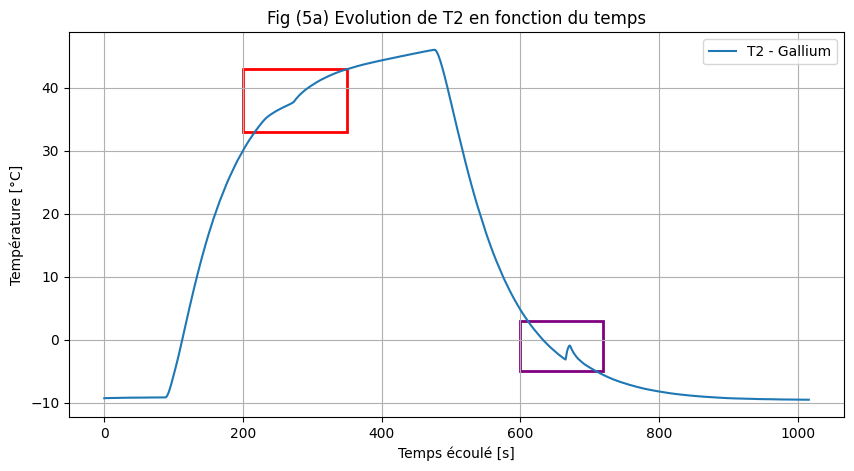

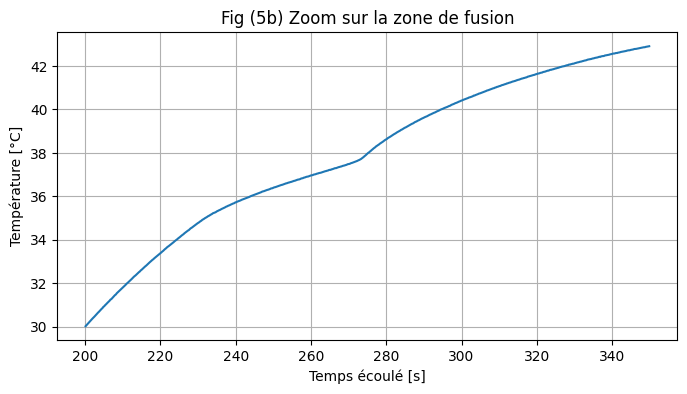

In [66]:
fig, ax = plt.subplots(figsize=(10,5))

# Courbe T2 uniquement
ax.plot(df["Elapsed_Time_s"], df["T2_C"], label="T2 - Gallium")

# Labels
ax.set_xlabel("Temps écoulé [s]")
ax.set_ylabel("Température [°C]")
ax.set_title("Fig (5a) Evolution de T2 en fonction du temps")
ax.legend()
ax.grid(True)

x1, x2 = 200, 350
y1, y2 = 33, 43

rect_red = patches.Rectangle(
    (x1, y1), x2-x1, y2-y1,
    linewidth=2, edgecolor='red', facecolor='none'
)
ax.add_patch(rect_red)

x3, x4 = 600, 720
y3, y4 = -5, 3

rect_purple = patches.Rectangle(
    (x3, y3), x4-x3, y4-y3,
    linewidth=2, edgecolor='purple', facecolor='none'
)
ax.add_patch(rect_purple)

plt.show()

# Filtrer la zone rouge
mask = (df["Elapsed_Time_s"] >= x1) & (df["Elapsed_Time_s"] <= x2)

plt.figure(figsize=(8,4))
plt.plot(df["Elapsed_Time_s"][mask], df["T2_C"][mask])

plt.xlabel("Temps écoulé [s]")
plt.ylabel("Température [°C]")
plt.title("Fig (5b) Zoom sur la zone de fusion")
plt.grid(True)

plt.show()


### Analyse de la courbe de $T_2$

La figure (5.a) montre l’évolution de la température du gallium en fonction du temps. La courbe de la chaleur ressemble à la courbe de la charge et de la décharge d’un condensateur dans un circuit RC. En effet, si on fait l’hypothèse que la température ne dépend que du temps, l’équation de la chaleur se résume à une équation différentielle ordinaire du 1 ordre similaire à la charge et décharge d’un condensateur dans un circuit RC.

Cependant, on peut remarquer qu’il y a deux zones sur la figure (5.a) où la pente change brusquement. Il y a soit un petit palier ou un petit pique. Ces deux irrégularités sont liées aux changements de phase du matériau. Lorsque que le gallium change de phase, l’énergie fournit ne sert plus seulement à augmenter sa température, mais également à se réarranger. On sait donc que notre température de fusion devrait se trouver dans les alentour de la zone rouge, car la fusion intervient lors du processus de chauffe.

### Méthodologie et traitement des données

On souhaite donc identifier les zones ou ma vitesse de chauffe du gallium ralentie, nous allons donc analyser les variations de $\dfrac{d^2 T_2(t)}{dt^2}$. Ensuite, nous utilisons la fonction `find_peaks` de la librairie python `scipy` qui permet d’identifier les extrema locaux. Les données dont nous disposions étaient bruités ce qui nous donnait un nombre conséquent d’extrema. Nous avons filtré les données grâce au filtre de Savitzky-Golay [3]. Nous l’avons choisi, car il permet de lisser les données sans déformer la tendance du signal.

### Résultat


Ruptures candidates :
Rupture 1: t = 90.5 s, T2 = -8.95 °C
Rupture 2: t = 105.4 s, T2 = -3.37 °C
Rupture 3: t = 232.3 s, T2 = 35.04 °C
Rupture 4: t = 272.8 s, T2 = 37.68 °C

Estimation fusion (3e rupture) :
t_fusion = 232.30 s
T_fusion = 35.04 °C


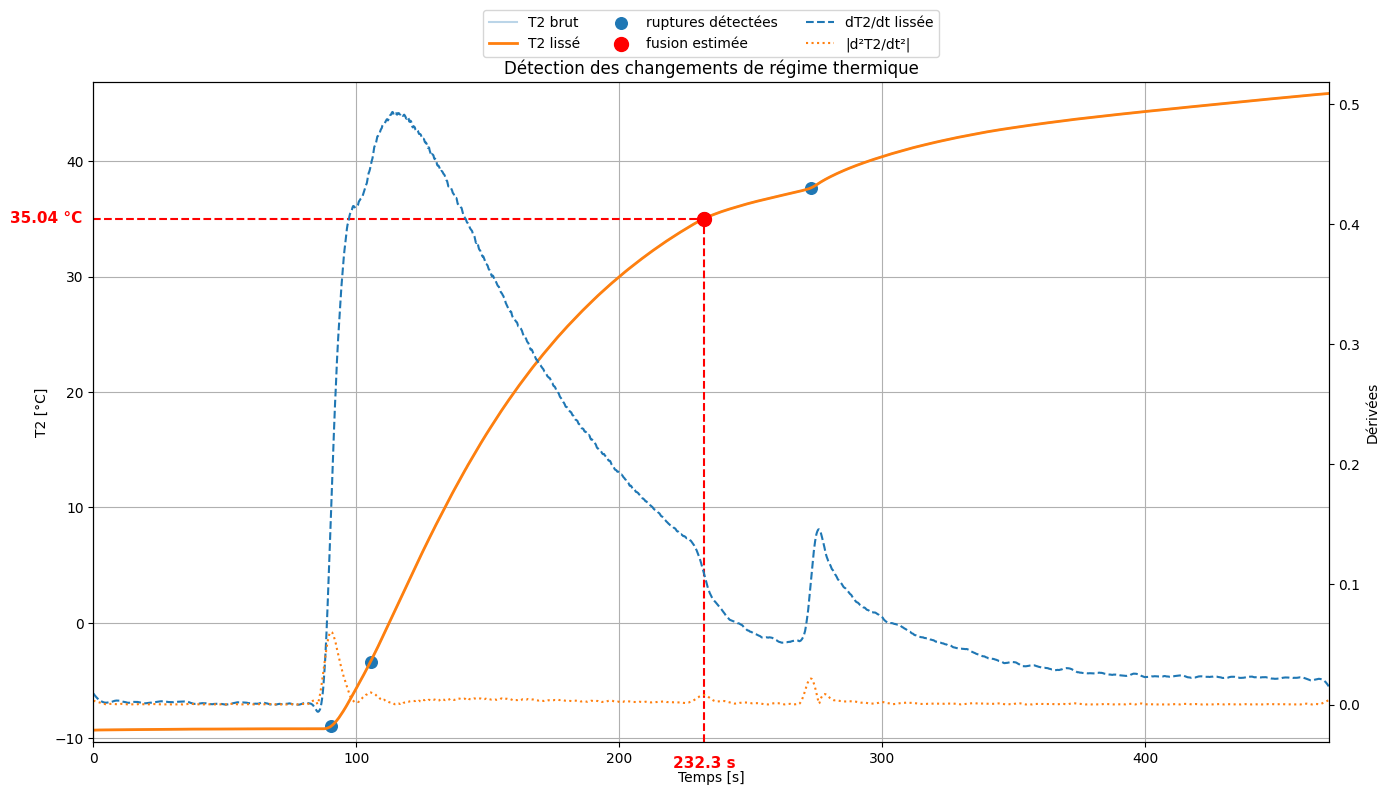

In [67]:

t = df["Elapsed_Time_s"].to_numpy()
T2 = df["T2_C"].to_numpy()

# =========================================================
# Phase de chauffe uniquement
# =========================================================
mask_heat = t < 470
t_heat = t[mask_heat]
T2_heat = T2[mask_heat]

# =========================================================
# Lissage de T2
# =========================================================
window = 31   # impair
poly = 3
T2_smooth = savgol_filter(T2_heat, window_length=window, polyorder=poly)

# =========================================================
# Dérivées
# =========================================================
dT2_dt = np.gradient(T2_smooth, t_heat)
dT2_dt_smooth = savgol_filter(dT2_dt, window_length=31, polyorder=3)

d2T2_dt2 = np.gradient(dT2_dt_smooth, t_heat)
d2T2_dt2_smooth = savgol_filter(d2T2_dt2, window_length=31, polyorder=3)

# =========================================================
# Détection des ruptures
# =========================================================
signal_break = np.abs(d2T2_dt2_smooth)

peaks, properties = find_peaks(
    signal_break,
    prominence=np.std(signal_break),
    distance=40
)

print("Ruptures candidates :")
for k, i in enumerate(peaks, start=1):
    print(f"Rupture {k}: t = {t_heat[i]:.1f} s, T2 = {T2_smooth[i]:.2f} °C")

# =========================================================
# Estimation de la fusion = 3e candidat
# =========================================================
if len(peaks) >= 3:
    i3 = peaks[2]
    t_fusion = t_heat[i3]
    T_fusion = T2[i3]

    print("\nEstimation fusion (3e rupture) :")
    print(f"t_fusion = {t_fusion:.2f} s")
    print(f"T_fusion = {T_fusion:.2f} °C")
else:
    raise ValueError("Moins de 3 ruptures détectées : impossible d'utiliser le 3e candidat.")

# =========================================================
# Tracé unique
# =========================================================
fig, ax1 = plt.subplots(figsize=(14, 8))

# courbes
ax1.plot(t_heat, T2_heat, alpha=0.3, label="T2 brut")
ax1.plot(t_heat, T2_smooth, linewidth=2, label="T2 lissé")
ax1.scatter(t_heat[peaks], T2_smooth[peaks], s=70, label="ruptures détectées")

# axe dérivée
ax2 = ax1.twinx()
ax2.plot(t_heat, dT2_dt_smooth, linestyle="--", label="dT2/dt lissée")
ax2.plot(t_heat, signal_break, linestyle=":", label="|d²T2/dt²|")
ax2.set_ylabel("Dérivées")

# limites
ax1.set_xlim(t_heat.min(), t_heat.max())
ax1.set_ylim(T2_heat.min() - 1, T2_heat.max() + 1)

xmin, xmax = ax1.get_xlim()
ymin, ymax = ax1.get_ylim()

# point fusion
ax1.scatter(t_fusion, T_fusion, color="red", s=100, zorder=5, label="fusion estimée")

# lignes pointillées vers les axes seulement
ax1.plot([t_fusion, t_fusion], [ymin, T_fusion],
         color="red", linestyle="--", linewidth=1.5)

ax1.plot([xmin, t_fusion], [T_fusion, T_fusion],
         color="red", linestyle="--", linewidth=1.5)

# valeur Tf sur l'axe des y
ax1.annotate(
    f"{T_fusion:.2f} °C",
    xy=(0, T_fusion),
    xycoords=ax1.get_yaxis_transform(),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color="red",
    fontsize=11,
    fontweight="bold"
)

# valeur tf sur l'axe des x
ax1.annotate(
    f"{t_fusion:.1f} s",
    xy=(t_fusion, 0),
    xycoords=ax1.get_xaxis_transform(),
    xytext=(0, -10),
    textcoords="offset points",
    ha="center",
    va="top",
    color="red",
    fontsize=11,
    fontweight="bold"
)

ax1.set_xlabel("Temps [s]")
ax1.set_ylabel("T2 [°C]")
ax1.grid(True)

# légende remontée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3
)

plt.title("Détection des changements de régime thermique")
plt.tight_layout()
plt.show()






Voici le tableau reprenant la valeur des différents points de ruptures

| Rupture | t [s] | T2 [$^\circ$C] |
|---:|---:|---:|
| 1 | 90.5 | -8.95 |
| 2 | 105.4 | -3.37 |
| 3 | 232.3 | 35.04 |
| 4 | 272.8 | 37.68 |

**Table 2 – Ruptures candidates identifiées dans l’évolution de $T_2(t)$.**

Nous avons donc 4 candidats pour la température de fusion. Nous pouvons éliminer les deux premiers candidats, car ils sont liés au processus de chauffe. Il reste à choisir entre le point de début et de fin du processus de fusion estimé. Nous avons décidé de choisir de prendre la température du début du processus de fusion comme approximation de la température de fusion. Ce choix est lié par le fait que notre système à une inertie thermique importante. Entre le capteur et le gallium, il y a une plaque de céramique qui a une résistance thermique non négligeable. Donc quand le capteur est à $35.04^\circ$, le gallium est une température moins élevée. On a donc comme estimation de température de fusion $T_f$

$$T_f = 35.04~^\circ\mathrm{C} \qquad (1)$$

Notre incertitude relative $\epsilon_r$ est donc

$$\epsilon_r = \frac{35.04 - 29.76}{29.76} \times 100 = 17\% \qquad (2)$$

### Source d’incertitude

On n’a une incertitude relative de 17%, cela démontre que notre processus d’estimation de la température n’est pas robuste et précis. Les sources d’incertitudes sont nombreuses.

Premièrement, notre outil de mesure possède une forte inertie thermique. La chaleur fournit par la cellule pelletier va d’abord passer par le capteur avant d’aller vers le gallium. En plus il y a entre eux une coupole en aluminium ainsi qu’une céramique Al$_2$O$_3$ qui est un matériau qui a une certaine résistance thermique. La température mesurée par la sonde et la température du gallium n’est pas la même, il y a une différence liée à la conduction thermique dans les différents matériaux. Pour améliorer cela, on pourrait soit appliquer de la pâte thermique qui favorise la conduction entre différents matériaux ou remplacer la céramique pas un matériau qui a une plus faible résistance thermique.

L’autre source d’incertitude est lié au traitement des données que nous avons faites. Le lissage des données avec le filtre de Savitzky-Golay va introduire une source d’incertitude qui va donc dépendre des paramètres du filtre qui sont `window_length` et `polyorder`.

Le lissage des données par filtre de Savitzky-Golay est utilisé uniquement pour détecter les changements de régime via les dérivées. Les valeurs de température et de temps sont ensuite relevées sur les données brutes, afin de ne pas altérer les mesures expérimentales. L’influence du filtre sur les résultats finaux est donc limitée. De plus, la température de fusion $T_f$ est identique, que l’on regarde les données lissées ou non, ce qui montre que le filtre n’introduit pas de biais significatif.

La fonction `find_peaks` possède comme paramètre la `distance`, qui impose une distance minimale entre deux pics détectés. Ce paramètre n’a pas d’impact significatif sur notre estimation de la température de fusion.

Si la valeur de `distance` est trop grande, certains pics pourraient ne pas être détectés. En particulier, les extrema associés aux changements de phase pourraient être ignorés s’ils sont considérés comme trop proches de ceux liés au processus global de chauffe.

À l’inverse, si la valeur de `distance` est trop petite, un plus grand nombre d’extrema peut être détecté, notamment en raison du bruit résiduel du signal. Cependant, dans notre cas, les pics pertinents sur la courbe de $\dfrac{d^2T_2(t)}{dt^2}$ sont bien distincts. De plus, le lissage appliqué à la dérivée seconde fait apparaître un cinquième pic, situé juste après le dernier pic détecté avec `distance = 40`. Ce pic supplémentaire correspond à la fin du processus de fusion et n’affecte pas l’identification du pic associé au début de la fusion, qui constitue notre estimateur de $T_f$.

Ainsi, le choix du paramètre `distance` n’influence pas la valeur finale de $T_f$ sauf si on prend comme paramètre une valeur aberrante.

Enfin, la vitesse de chauffe a aussi pu avoir un impact. En effet, une vitesse plus lente permet de voir plus distinctement le pallier lié au changement d’état. Enfin, la résolution des capteurs qui est de $\pm 0{,}1^\circ$ C aurait peu avoir un impact minime sur la précision de notre mesure. Le couvercle thermique n’isolant pas parfaitement peut aussi être une source d’incertitude.



<div class="question-box">

### Q8  
À partir de la courbe $\Delta T(t)$, relevez pour chaque transition (fusion et solidification) :

- l’instant de début et de fin (en secondes),
- la durée du plateau de transition,
- la valeur maximale de $|\Delta T|$.

Présentez vos résultats dans un tableau récapitulatif.

</div>

<div class="answer-box">

### Réponse

#### Méthodologie :

Nous avons essayé d’appliquer la même méthode qu’à la question 7 pour automatiser la détection de piques dans la mesure de la différence de température, mais nous n’avons pas réussi à avoir un résultat lisible dans la mesure où beaucoup trop d’extrema était trouvé par la fonction `find_peaks` peu importe les paramètres. Nous avons donc regardé manuellement sur la dérivée les valeurs des temps pour lesquelles, nous observions un grand changement de pente et ensuite la valeur de la différence de température correspondante sur le graphique.

#### 1.4.1 Résultat :
</div>


<table>
  <thead>
    <tr>
      <th>Transition</th>
      <th>Début t [s]</th>
      <th>Fin t [s]</th>
      <th>Durée du plateau [s]</th>
      <th>|ΔT|max [°C]</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Fusion</td>
      <td>228.44</td>
      <td>311.39</td>
      <td>82.95</td>
      <td>1.82</td>
    </tr>
    <tr>
      <td>Solidification</td>
      <td>661.21</td>
      <td>714.93</td>
      <td>53.72</td>
      <td>3.41</td>
    </tr>
  </tbody>
</table>

<div class="figure-caption">
Table 3 – Caractéristiques des transitions de phase déterminées à partir de la courbe ΔT(t).
</div>


<div class="question-box">

### Q9  
Observez-vous un phénomène de surfusion (supercooling) lors de la solidification sur la courbe $T_2(t)$ ? Si oui, estimez son amplitude $\Delta T_{\text{surf}}$ et sa durée. Expliquez brièvement le mécanisme physique à l’origine de ce phénomène.

</div>

<div class="answer-box">

### Réponse

Le phénomène de surfusion est l’état d’un corps qui reste en phase liquide alors que sa température est inférieure à la température de solidification ordinaire.

</div>



Selon les informations indiquées dans la fiche des consignes, le point de fusion du gallium, c’est-à-dire la température où le métal passe de l’état solide à l’état liquide est de 29,76°C. Par déduction, nous pouvons dire que le point de solidification théorique (c’est-à-dire le phénomène inverse) est également à cette valeur. Donc $T_{\mathrm{solid}} = 29{,}76^\circ$ C.

Nous remarquons que la température où le gallium commence sa solidification se trouve bien après notre température déduite. Par conséquent l’état métal jusqu’au moment du début de la solidification reste liquide. Nous pouvons donc parler d’une phase de surfusion, c’est-à-dire la durée dans laquelle le métal est inférieure à $T_{\mathrm{solid}}$ jusqu’à qu’il se solidifie.

En considérant que le temps où le métal descend sous $T_{\mathrm{solid}}$ vaut 517 s et celui où il commence à se solidifier vaut 663 s, la durée $\Delta t$ du phénomène de surfusion vaut approximativement 146 s.

L’amplitude $\Delta T_{\text{surf}}$ mesure le saut thermique provoqué par la libération de la chaleur latente durant la transition. Ce sursaut représente la différence entre le point le plus froid avant d’effectuer la transition et la température à laquelle le système parvient à se stabiliser, c’est-à-dire la température maximale durant le plateau. Donc l’amplitude $\Delta T_{\text{surf}}$ vaut donc :

$$\Delta T_{\text{surf}} = T_{\text{plateau}} - T_{\min}$$

$$\Delta T_{\text{surf}} \approx (-1.1) - (-3.2) = 2.1~^\circ\mathrm{C}$$



## 1.5 Estimation de la chaleur latente (question ouverte)

<div class="question-box">

### Q10  
En supposant une puissance de chauffe constante $P$ (W), la pente $\dfrac{dT_1}{dt}$ (K/s) est proportionnelle à $P$. Proposez et appliquez une méthode pour estimer qualitativement la chaleur latente de fusion du gallium $L_f$ à partir de :

- la pente de $T_1(t)$ hors transition,
- la durée du plateau de fusion,
- la masse approximative de l’échantillon (fournie par l’assistant).

Comparez votre estimation à la valeur tabulée ($L_f = 80.1$ kJ/kg) et discutez les hypothèses et limites.

</div>

<div class="answer-box">

### Réponse

Une méthode d’estimation de la chaleur latente $L_f$ serait de calculer l’enthalpie fournie pendant la fusion $\Delta H_{\text{fusion}}$ et l’énergie dégagées pendant le plateau $Q_{\text{plateau}}$. Ces deux énergies peuvent être calculées par les formules suivantes :

$$\Delta H_{\text{fusion}} = m \cdot L_f \qquad (3)$$

$$Q_{\text{plateau}} = P \cdot \Delta t \qquad (4)$$

Avec $P$ qui représente la puissance de chauffe et qui peut être réécrit par la formule $P = m \cdot c_p \cdot \dfrac{dT_1}{dt}$.

Par conséquent, l’équation de l’énergie fournie par le tableau vaut :

$$Q_{\text{plateau}} = m \cdot c_p \cdot \dfrac{dT_1}{dt} \cdot \Delta t \qquad (5)$$

En admettant que $Q_{\text{fusion}} = \Delta H_{\text{fusion}}$, nous puissions égaliser les deux énergies afin d’isoler la chaleur de latente $L_f$. Nous obtenons finalement l’expression de la chaleur de latente $L_f$ suivante :

$$L_f = c_p \cdot \dfrac{dT_1}{dt} \cdot \Delta t_{\text{fusion}} \qquad (6)$$

Cependant, la pente hors transition $\dfrac{dT_1}{dt}$ reste à calculer. Pour cela, nous effectuons une régression linéaire sur un intervalle de temps qui va du début jusqu’à la fin de l’échauffement. Pour nos calculs, en observant la figure 1, nous prenons le temps initial $t_1 = 93$ s et le temps final $t_2 = 250$ s. Nous obtenons finalement une valeur de $\dfrac{dT_1}{dt} \approx 0.28~^\circ\mathrm{C/s}$.

En prenant les valeurs calculées et celles tubulées :

| $c_p$ | $\dfrac{dT_1}{dt}$ | $\Delta t_{\text{fusion}}$ |
|---:|---:|---:|
| 0.372 J/(gK˙ ) | 0.28 °C/s | 82.95 s |

<div class="figure-caption">Table 4 – Valeurs de données</div>

Nous obtenons donc une approximation de la chaleur de latente :

$$L_f \approx 8.64~\text{kJ/kg}.$$

Cette valeur expérimentale est très basse à celle tubulée ($L_f = 80.1$ kJ/kg). Ce résultat peut s’expliquer par le fait que notre méthode se repose sur plusieurs hypothèses qui ont leurs limites.

#### Hypothèses :

Tout d’abord, nous mettons l’hypothèse que l’échantillon de gallium reçoit exactement la même puissance thermique que le capteur $\Rightarrow P_{\text{gallium}} = P_{\text{capteur}}$.

Ensuite, nous supposons que la puissance de chauffe $P$ est constante. Cela induit que la pente $\dfrac{dT_1}{dt}$ du capteur est stable.

Enfin, nous mettons l’hypothèse que l’énergie absorbée durant le plateau sert uniquement à la fusion du gallium. $Q_{\text{fusion}} = m \cdot L_f$.

#### Limites :

Tout d’abord, la puissance de chauffe $P$ chauffe que le gallium. En effet, la puissance chauffe également le capteur, les fils et le support. Par conséquent, nous sous-estimons massivement la puissance réelle absorbée.

Par la suite, nous faisons une approximation linéaire afin de calculer la pente de $T_1$ pour notre approche. Or la chauffe n’est pas linéaire, mais courbée. Par conséquent, l’estimation de la puissance $P$ est imprécise.

Ensuite, nous pouvons parler des conditions expérimentales auxquelles le gallium a été chauffé. Si le système n’est pas parfaitement isolé, cela induirait à une perte de chaleur qui se dissiperait dans l’air.

Nous pouvons également ajouter si le contact entre le capteur 2 et le gallium n’est pas parfait, le capteur pourrait avoir un retard sur la transition ou une atténuation, ce qui fausse la mesure du temps $\Delta t_{\text{fusion}}$.

Enfin, la résolution du capteur (7,8 m°C) et sa précision ($\pm 0{,}1^\circ$ C) limitent la précision des mesures de la pente $\dfrac{dT_1}{dt}$ et de détection exacte du début et de la fin du plateau lors de la fusion.

</div>



# Références

[1] Contributeurs. *Chaleur Latente*. 2026.  
url : https://www.lachimie.fr/thermodynamique/chaleur-latente.php.

[2] Wikipedia contributors. *Differential scanning calorimetry*. 2026.  
url : https://en.wikipedia.org/wiki/Differential_scanning_calorimetry (visité le 06/03/2026).

[3] Wikipedia contributors. *Savitzky–Golay filter*. 2026.  
url : https://en.wikipedia.org/wiki/Savitzky_Golay_filter (visité le 23/02/2026).

---

